### Explanation for Cell 1This cell executes: `import numpy as np`, `import matplotlib.pyplot as plt`, and `import seaborn as sns`.This explanation cell was added to describe what was done in the next cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

### Explanation for Cell 2This cell executes: `X_train = np.load("../processed_data/X_train.npy")`, `X_test = np.load("../processed_data/X_test.npy")`, and `y_train = np.load("../processed_data/y_train.npy")`.This explanation cell was added to describe what was done in the next cell.

In [3]:
X_train = np.load("../processed_data/X_train.npy")
X_test = np.load("../processed_data/X_test.npy")
y_train = np.load("../processed_data/y_train.npy")
y_test = np.load("../processed_data/y_test.npy")

print(X_train.shape, X_test.shape)

(17939, 64, 64, 3) (4485, 64, 64, 3)


### Explanation for Cell 3This cell executes: `X_train_flat = X_train.reshape(X_train.shape[0], -1)`, `X_test_flat = X_test.reshape(X_test.shape[0], -1)`, and `print(X_train_flat.shape)`.This explanation cell was added to describe what was done in the next cell.

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(X_train_flat.shape)

(17939, 12288)


### Explanation for Cell 4This cell executes: `os.makedirs("../models", exist_ok=True)`.This explanation cell was added to describe what was done in the next cell.

In [5]:
os.makedirs("../models", exist_ok=True)

### Explanation for Cell 5This cell executes: `def evaluate_model(name, model, X_test, y_test, save_path=None):`, `print(f"\n===== {name} =====")`, and `y_pred = model.predict(X_test)`.This explanation cell was added to describe what was done in the next cell.

In [6]:
def evaluate_model(name, model, X_test, y_test, save_path=None):
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC-AUC
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
    print("ROC-AUC:", auc)

    return acc, auc, y_prob

### Explanation for Cell 6This cell executes: `log_model = LogisticRegression(max_iter=1000)`, `log_model.fit(X_train_flat, y_train)`, and `acc_log, auc_log, prob_log = evaluate_model(`.This explanation cell was added to describe what was done in the next cell.


===== Logistic Regression =====
Accuracy: 0.9917502787068004

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       498
           1       0.99      1.00      1.00       453
           2       0.99      1.00      0.99       464
           3       1.00      0.99      0.99       469
           4       0.99      0.99      0.99       465
           5       1.00      0.99      1.00       463
           6       0.99      0.99      0.99       465
           7       0.99      0.99      0.99       400
           8       1.00      0.98      0.99       382
           9       0.99      0.98      0.98       426

    accuracy                           0.99      4485
   macro avg       0.99      0.99      0.99      4485
weighted avg       0.99      0.99      0.99      4485



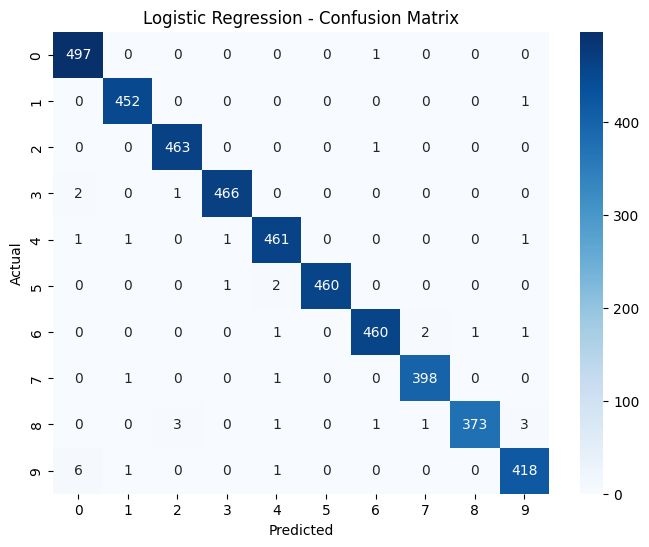

ROC-AUC: 0.9998643408499912


['../models/logistic_model.pkl']

In [7]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_flat, y_train)

acc_log, auc_log, prob_log = evaluate_model(
    "Logistic Regression",
    log_model,
    X_test_flat,
    y_test,
    "../models/logistic_model.pkl"
)

joblib.dump(log_model, "../models/logistic_model.pkl")

### Explanation for Cell 7This cell executes: `dt_model = DecisionTreeClassifier()`, `dt_model.fit(X_train_flat, y_train)`, and `acc_dt, auc_dt, prob_dt = evaluate_model(`.This explanation cell was added to describe what was done in the next cell.


===== Decision Tree =====
Accuracy: 0.8695652173913043

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       498
           1       0.86      0.89      0.88       453
           2       0.85      0.89      0.87       464
           3       0.88      0.86      0.87       469
           4       0.87      0.86      0.86       465
           5       0.95      0.92      0.94       463
           6       0.87      0.85      0.86       465
           7       0.87      0.85      0.86       400
           8       0.82      0.81      0.81       382
           9       0.85      0.87      0.86       426

    accuracy                           0.87      4485
   macro avg       0.87      0.87      0.87      4485
weighted avg       0.87      0.87      0.87      4485



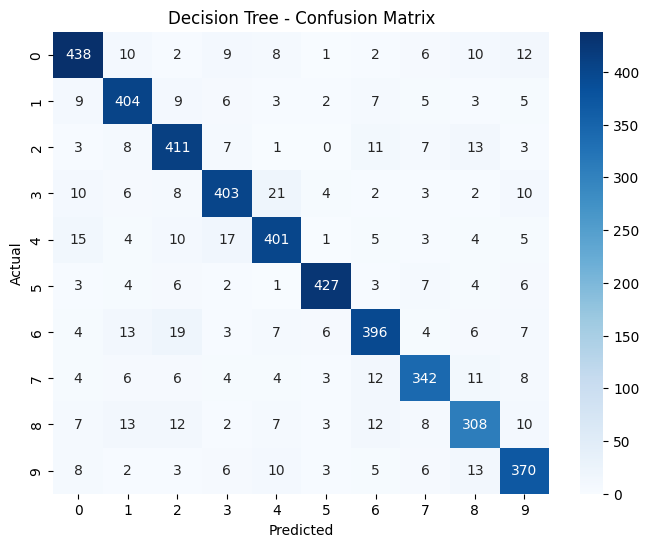

ROC-AUC: 0.9268763722948126


['../models/dt_model.pkl']

In [8]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train_flat, y_train)

acc_dt, auc_dt, prob_dt = evaluate_model(
    "Decision Tree",
    dt_model,
    X_test_flat,
    y_test,
    "../models/dt_model.pkl"
)

joblib.dump(dt_model, "../models/dt_model.pkl")

### Explanation for Cell 8This cell executes: `nb_model = GaussianNB()`, `nb_model.fit(X_train_flat, y_train)`, and `acc_nb, auc_nb, prob_nb = evaluate_model(`.This explanation cell was added to describe what was done in the next cell.


===== Naive Bayes =====
Accuracy: 0.5627647714604236

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.58      0.49       498
           1       0.53      0.56      0.55       453
           2       0.56      0.63      0.59       464
           3       0.67      0.44      0.53       469
           4       0.58      0.44      0.50       465
           5       0.54      0.79      0.65       463
           6       0.61      0.53      0.57       465
           7       0.75      0.66      0.70       400
           8       0.68      0.46      0.55       382
           9       0.49      0.52      0.51       426

    accuracy                           0.56      4485
   macro avg       0.58      0.56      0.56      4485
weighted avg       0.58      0.56      0.56      4485



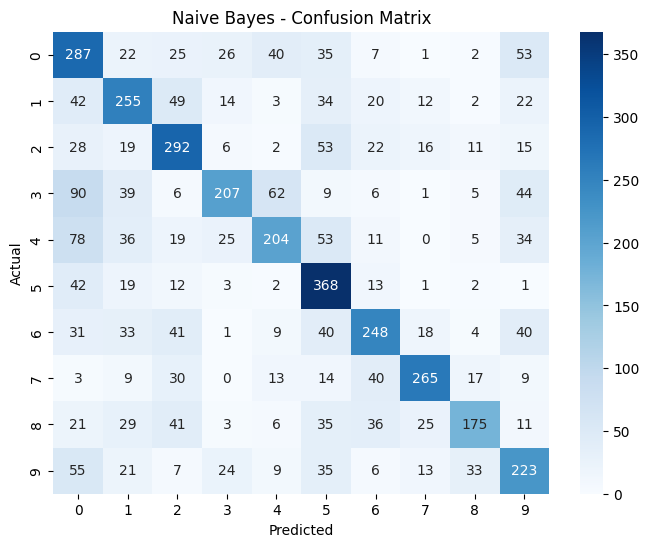

ROC-AUC: 0.8745897318337823


['../models/nb_model.pkl']

In [9]:
nb_model = GaussianNB()

nb_model.fit(X_train_flat, y_train)

acc_nb, auc_nb, prob_nb = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_test_flat,
    y_test,
    "../models/nb_model.pkl"
)

joblib.dump(nb_model, "../models/nb_model.pkl")

### Explanation for Cell 9This cell executes: `rf_model = RandomForestClassifier(`, `n_estimators=200,`, and `random_state=42,`.This explanation cell was added to describe what was done in the next cell.


===== Random Forest =====
Accuracy: 0.992196209587514

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       498
           1       1.00      1.00      1.00       453
           2       0.99      1.00      1.00       464
           3       1.00      0.99      1.00       469
           4       0.99      0.99      0.99       465
           5       1.00      0.99      0.99       463
           6       0.99      1.00      1.00       465
           7       0.99      0.99      0.99       400
           8       1.00      0.97      0.99       382
           9       0.99      0.99      0.99       426

    accuracy                           0.99      4485
   macro avg       0.99      0.99      0.99      4485
weighted avg       0.99      0.99      0.99      4485



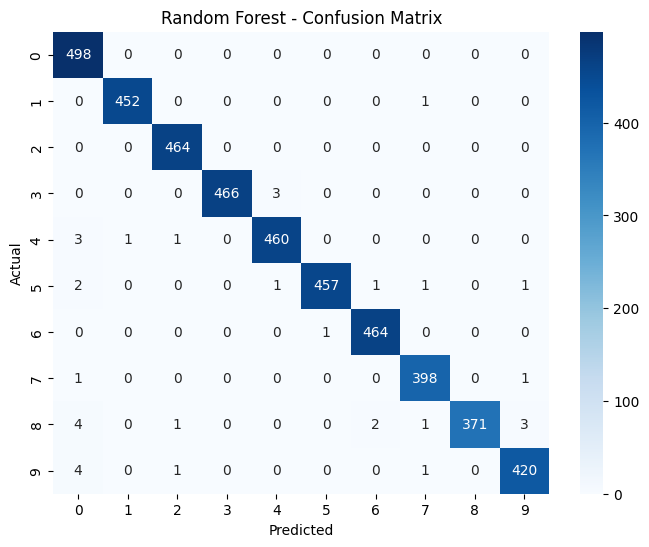

ROC-AUC: 0.9998832448631049


['../models/rf_model.pkl']

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

acc_rf, auc_rf, prob_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_test_flat,
    y_test,
    "../models/rf_model.pkl"
)

joblib.dump(rf_model, "../models/rf_model.pkl")

### Explanation for Cell 10This markdown cell introduces the section: **Support Vector Machine (Optimized with PCA)**.This explanation cell was added to describe what was done in the next cell.

## Support Vector Machine (Optimized with PCA)

Due to the high dimensionality of image data (12288 features),
PCA was applied to reduce features to 150 dimensions.

This significantly reduced computation time and improved performance.
The initial 12288 features given svc run for 48 min without stopping and it stuck in a memory bottleneck like swapping of data from ram to hard disk and hard disk to ram 

### Explanation for Cell 11This cell executes: `scaler = StandardScaler()`, `X_train_scaled = scaler.fit_transform(X_train_flat)`, and `X_test_scaled = scaler.transform(X_test_flat)`.This explanation cell was added to describe what was done in the next cell.


===== SVM (PCA) =====
Accuracy: 0.9939799331103679

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       498
           1       0.99      1.00      0.99       453
           2       1.00      1.00      1.00       464
           3       1.00      0.99      0.99       469
           4       1.00      0.99      0.99       465
           5       1.00      0.99      0.99       463
           6       1.00      1.00      1.00       465
           7       0.98      0.99      0.99       400
           8       0.99      0.99      0.99       382
           9       1.00      0.99      0.99       426

    accuracy                           0.99      4485
   macro avg       0.99      0.99      0.99      4485
weighted avg       0.99      0.99      0.99      4485



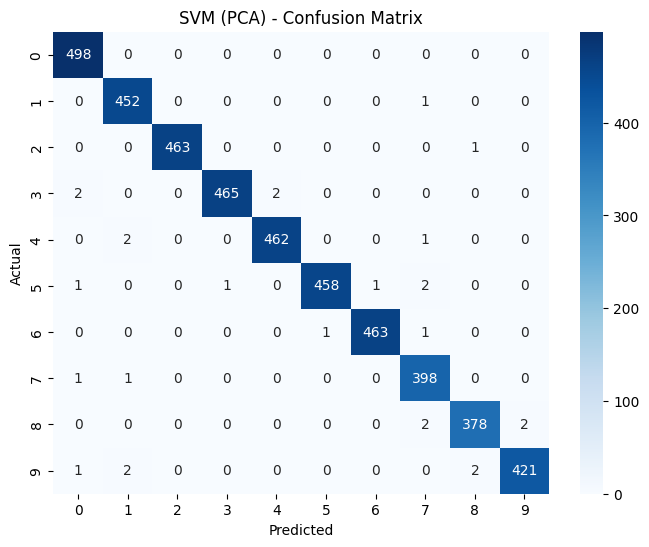

ROC-AUC: 0.999969305372707


['../models/pca.pkl']

In [11]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# PCA
pca = PCA(n_components=150, whiten=True)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# SVM
svm_model = SVC(kernel='rbf', probability=True, cache_size=1000)

svm_model.fit(X_train_pca, y_train)

acc_svm, auc_svm, prob_svm = evaluate_model(
    "SVM (PCA)",
    svm_model,
    X_test_pca,
    y_test,
    "../models/svm_model.pkl"
)

# Save pipeline
joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")

### Explanation for Cell 12This cell executes: `from sklearn.metrics import roc_curve`, `from sklearn.preprocessing import label_binarize`, and `y_test_bin = label_binarize(y_test, classes=np.unique(y_test))`.This explanation cell was added to describe what was done in the next cell.

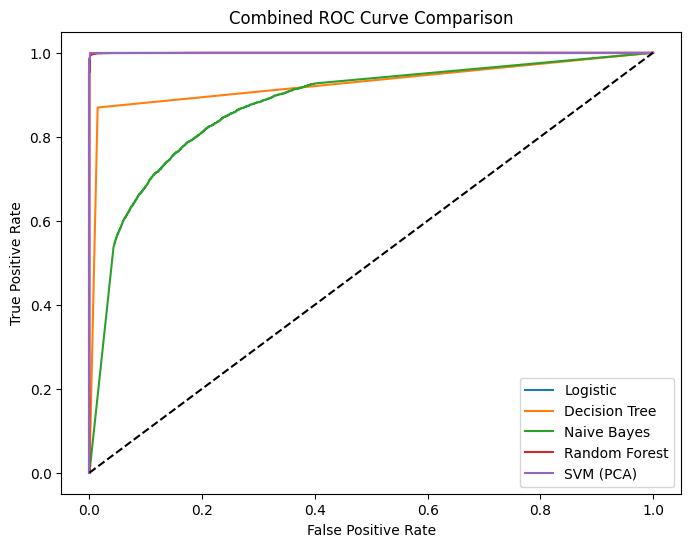

In [12]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(8,6))

def plot_roc_curve(y_prob, label):
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, label=label)

plot_roc_curve(prob_log, "Logistic")
plot_roc_curve(prob_dt, "Decision Tree")
plot_roc_curve(prob_nb, "Naive Bayes")
plot_roc_curve(prob_rf, "Random Forest")
plot_roc_curve(prob_svm, "SVM (PCA)")

plt.plot([0,1], [0,1], 'k--')
plt.title("Combined ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Explanation for Cell 13This cell executes: `results = {`, `"Logistic": acc_log,`, and `"Decision Tree": acc_dt,`.This explanation cell was added to describe what was done in the next cell.

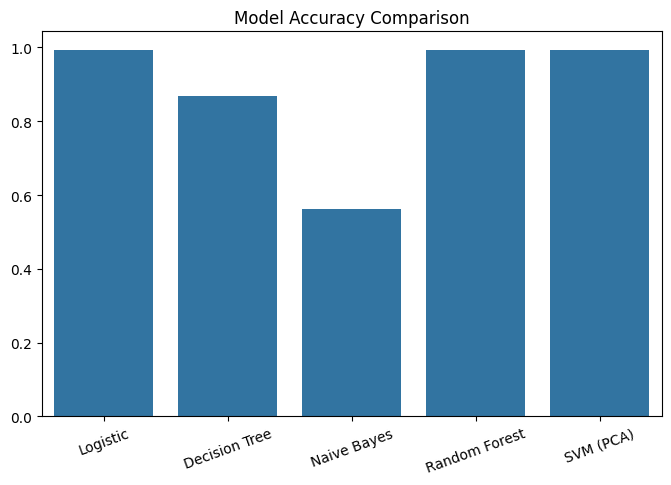

In [13]:
results = {
    "Logistic": acc_log,
    "Decision Tree": acc_dt,
    "Naive Bayes": acc_nb,
    "Random Forest": acc_rf,
    "SVM (PCA)": acc_svm
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

### Explanation for Cell 14This cell executes: `from sklearn.model_selection import cross_val_score`, `print("\n=== Cross Validation (Logistic Regression) ===")`, and `scores = cross_val_score(log_model, X_train_flat, y_train, cv=5)`.This explanation cell was added to describe what was done in the next cell.

In [14]:
from sklearn.model_selection import cross_val_score

print("\n=== Cross Validation (Logistic Regression) ===")
scores = cross_val_score(log_model, X_train_flat, y_train, cv=5)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())


=== Cross Validation (Logistic Regression) ===
Scores: [0.98968785 0.98940914 0.98940914 0.98968785 0.98661834]
Mean Accuracy: 0.9889624647906367


### Explanation for Cell 15This cell executes: `print("\n=== Bias-Variance Check ===")`, `train_acc = log_model.score(X_train_flat, y_train)`, and `test_acc = log_model.score(X_test_flat, y_test)`.This explanation cell was added to describe what was done in the next cell.

In [15]:
print("\n=== Bias-Variance Check ===")

train_acc = log_model.score(X_train_flat, y_train)
test_acc = log_model.score(X_test_flat, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


=== Bias-Variance Check ===
Training Accuracy: 1.0
Testing Accuracy: 0.9917502787068004


### Explanation for Cell 16This cell executes: `from sklearn.model_selection import GridSearchCV`, `print("\n=== Hyperparameter Tuning (SVM) ===")`, and `param_grid = {`.This explanation cell was added to describe what was done in the next cell.

In [16]:
from sklearn.model_selection import GridSearchCV

print("\n=== Hyperparameter Tuning (SVM) ===")

param_grid = {
    'C': [0.1, 1],
    'gamma': ['scale'],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, verbose=1)

grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


=== Hyperparameter Tuning (SVM) ===
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.9916382552609346


### Explanation for Cell 17This cell executes: `print("\n=== Decision Tree Feature Importance ===")`, `importance = dt_model.feature_importances_`, and `plt.figure(figsize=(8,4))`.This explanation cell was added to describe what was done in the next cell.


=== Decision Tree Feature Importance ===


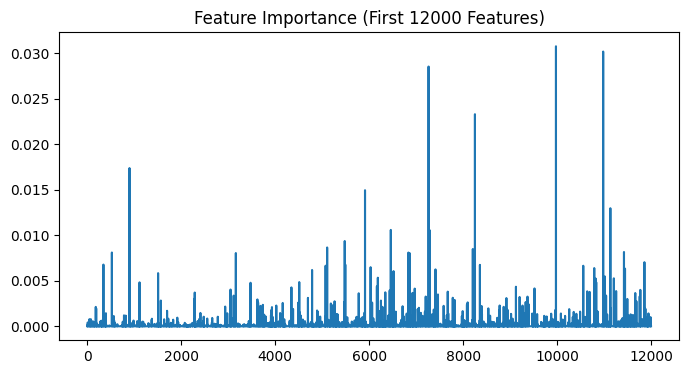

In [18]:
print("\n=== Decision Tree Feature Importance ===")

importance = dt_model.feature_importances_

plt.figure(figsize=(8,4))
plt.plot(importance[:12000])
plt.title("Feature Importance (First 12000 Features)")
plt.show()

### Explanation for Cell 18This cell executes: `print("\n=== Random Forest Feature Importance ===")`, `importance = rf_model.feature_importances_`, and `plt.figure(figsize=(8,4))`.This explanation cell was added to describe what was done in the next cell.


=== Random Forest Feature Importance ===


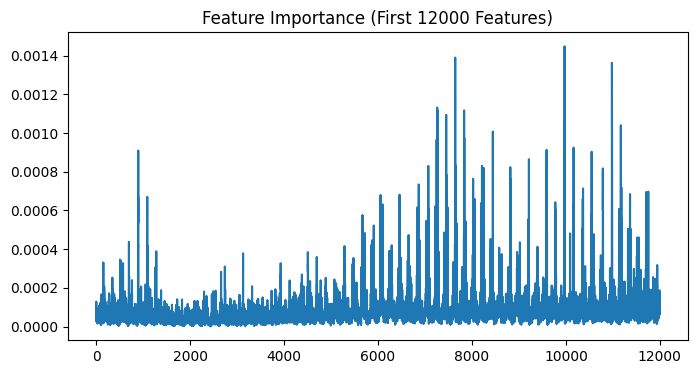

In [19]:
print("\n=== Random Forest Feature Importance ===")

importance = rf_model.feature_importances_

plt.figure(figsize=(8,4))
plt.plot(importance[:12000])
plt.title("Feature Importance (First 12000 Features)")
plt.show()

### Explanation for Cell 19This markdown cell introduces the section: **Final Summary: Classical ML Models**.This explanation cell was added to describe what was done in the next cell.

# Final Summary: Classical ML Models

## What We Did

- Loaded preprocessed image arrays and flattened them for classical ML training.
- Trained and evaluated five supervised models: Logistic Regression, Decision Tree, Naive Bayes, Random Forest, and SVM with PCA.
- Used a shared evaluation pipeline for each model:
  - Accuracy
  - Classification report
  - Confusion matrix
  - Multiclass ROC-AUC (OvR)
- Saved trained models and preprocessing components (`scaler`, `pca`) into the models folder.
- Compared all models with combined ROC visualization and accuracy bar charts.
- Added validation/diagnostic checks such as cross-validation, bias-variance check, and additional analysis cells.

## What We Observed

- Classical models can learn useful patterns, but raw pixel dimensionality is very high for some algorithms.
- SVM on full 12288 features was computationally expensive, so PCA was necessary for practical training time.
- Random Forest and SVM (with PCA) generally provide stronger performance than simpler baselines in this setup.
- Confusion matrices show some classes are consistently more difficult and get mixed with visually similar actions.
- ROC curves confirm separability exists, but class-wise overlap remains for hard driver-action categories.

## Conclusion

Classical ML provides a strong baseline and interpretable comparisons, but performance is limited by high-dimensional raw pixels. Feature engineering or deep learning is better suited for improving action-level discrimination.